In [7]:
from __future__ import annotations

import logging
import math
import os
import time
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import KFold
from joblib import Parallel, delayed

try:
    from scipy import special as scipy_special  # type: ignore
    from scipy import stats as scipy_stats  # type: ignore
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from threadpoolctl import threadpool_limits
    HAS_THREADPOOLCTL = True
except Exception:
    HAS_THREADPOOLCTL = False

LOGGER = logging.getLogger(__name__)
if not LOGGER.handlers:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

plt.style.use("default")


# =============================================================================
# Configuration
# =============================================================================

@dataclass
class PricingDGPConfig:
    """
    Dynamic pricing DGP with hidden customer heterogeneity and a hidden internal
    reference price.

    Sequential unconfoundedness holds by construction because the behavior policy
    depends only on observed history S_t:
        S_t = (X_1, A_1, R_1, ..., X_{t-1}, A_{t-1}, R_{t-1}, X_t).

    Hidden objects:
      - wtp_i: baseline willingness to pay
      - alpha_i: customer-specific reference updating speed
      - r*_it: internal reference price, not observed by the policy or analyst

    Observed state X_t is intentionally low-dimensional and realistic:
      - last price
      - average past price
      - last revenue
      - average past revenue
      - seasonality (sin / cos)

    This keeps the pricing policy simple enough that the score side is learnable,
    while the q-side remains genuinely hard because long-run outcomes depend on a
    latent filtered state.
    """

    T: int = 8
    gamma: float = 0.99

    # Price support / behavior policy
    p_min: float = 1.0
    p_max: float = 10.0
    sigma_price: float = 0.70

    # Latent heterogeneity
    sigma_wtp: float = 1.00
    alpha_min: float = 0.72
    alpha_max: float = 0.97
    alpha_scale: float = 1.10

    # Hidden internal reference
    r0_mean: float = 5.20
    r0_std: float = 0.85
    hidden_ref_wtp_loading: float = 0.60
    hidden_ref_init_noise: float = 0.35
    hidden_ref_noise: float = 0.12

    # Behavior policy mean (observed-history only)
    mu_intercept: float = 2.90
    mu_last_price: float = 0.25
    mu_avg_price: float = 0.18
    mu_last_revenue: float = 0.28
    mu_avg_revenue: float = 0.18
    mu_gap: float = 0.15
    mu_sin: float = 0.18
    mu_cos: float = -0.10
    mu_target_revenue: float = 2.70
    mu_revenue_scale: float = 2.20
    mu_margin_from_boundary: float = 0.55

    # Demand / purchase model
    beta0: float = 2.00
    beta_price: float = -0.72
    beta_ref: float = 0.78
    beta_gap2: float = 0.18
    beta_season: float = 0.20
    beta_price_nonlin: float = 0.14

    # Optional persistent latent taste shock to strengthen partial observability
    latent_state_persistence: float = 0.88
    latent_state_noise: float = 0.22
    latent_state_loading: float = 0.40


@dataclass
class LearnerConfig:
    # Shared pooled q-network across stages within a fold
    hidden_dim_q: int = 128
    depth_q: int = 2
    dropout_q: float = 0.00

    # Shared pooled score network across stages within a fold
    hidden_dim_h: int = 128
    depth_h: int = 3
    dropout_h: float = 0.00

    activation: str = "silu"

    lr_q: float = 6e-4
    lr_h: float = 6e-4
    weight_decay_q: float = 1e-4
    weight_decay_h: float = 1e-4

    batch_size_q: int = 1024
    batch_size_h: int = 1024
    epochs_q: int = 45
    epochs_h: int = 60
    val_fraction: float = 0.10
    patience: int = 8
    grad_clip: float = 5.0

    # Finite differences for the direct plug-in
    q_fd_step_scale: float = 0.05
    q_fd_step_min: float = 0.01
    q_fd_step_max: float = 0.25

    # Auto-DML quadratic variational objective for H
    h_fd_step_scale: float = 0.05
    h_fd_step_min: float = 0.01
    h_fd_step_max: float = 0.20
    h_grad_penalty: float = 5e-5
    interior_tol: float = 1e-8

    pred_batch_size: int = 8192


@dataclass
class MonteCarloConfig:
    N: int = 5000
    R: int = 100
    n_folds: int = 5

    oracle_eps: float = 0.05
    oracle_mc: int = 150_000
    oracle_seed: int = 999

    n_jobs: int = 1
    worker_torch_threads: int = 1
    use_cuda_when_possible: bool = True

    se_method: str = "iid"   # 'iid' or 'fold_cluster'
    verbose: bool = True


@dataclass
class Standardizer:
    eps: float = 1e-8
    S_mean: Optional[np.ndarray] = None
    S_std: Optional[np.ndarray] = None
    A_mean: Optional[float] = None
    A_std: Optional[float] = None

    def fit(self, S: np.ndarray, A: np.ndarray) -> "Standardizer":
        S = np.asarray(S, dtype=np.float32)
        A = np.asarray(A, dtype=np.float32).reshape(-1, 1)
        self.S_mean = S.mean(axis=0, keepdims=True)
        self.S_std = np.maximum(S.std(axis=0, keepdims=True), self.eps)
        self.A_mean = float(A.mean())
        self.A_std = float(max(A.std(), self.eps))
        return self

    def transform_S(self, S: np.ndarray) -> np.ndarray:
        if self.S_mean is None or self.S_std is None:
            raise ValueError("Standardizer must be fit before transform_S.")
        S = np.asarray(S, dtype=np.float32)
        return ((S - self.S_mean) / self.S_std).astype(np.float32)

    def transform_A(self, A: np.ndarray) -> np.ndarray:
        if self.A_mean is None or self.A_std is None:
            raise ValueError("Standardizer must be fit before transform_A.")
        A = np.asarray(A, dtype=np.float32).reshape(-1, 1)
        return ((A - self.A_mean) / self.A_std).astype(np.float32)


@dataclass
class FoldModels:
    q_model: nn.Module
    h_model: nn.Module
    q_standardizer: Standardizer
    h_standardizer: Standardizer
    max_s_dim: int


@dataclass
class CrossFitResult:
    theta_direct: float
    theta_asrw: float
    theta_asrw_oracle: float
    theta_srw: float

    contrib_direct: np.ndarray
    contrib_asrw: np.ndarray
    contrib_asrw_oracle: np.ndarray
    contrib_srw: np.ndarray

    fold_means: Dict[str, np.ndarray]
    fold_weights: np.ndarray


# =============================================================================
# Utilities
# =============================================================================

def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choose_device(use_cuda: bool) -> torch.device:
    if use_cuda and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def _limit_threads(n_threads: int):
    if HAS_THREADPOOLCTL:
        return threadpool_limits(limits=n_threads)

    class _NoOp:
        def __enter__(self):
            return None
        def __exit__(self, exc_type, exc, tb):
            return False

    return _NoOp()


def _sigmoid(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    return 1.0 / (1.0 + np.exp(-x))


def _build_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    return nn.SiLU()


def _student_critical_95(df: int) -> float:
    if HAS_SCIPY:
        return float(scipy_stats.t.ppf(0.975, df))
    return 1.959963984540054


def _logphi(z: np.ndarray) -> np.ndarray:
    return -0.5 * z ** 2 - 0.5 * np.log(2.0 * np.pi)


def _logcdf_std_normal(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    if HAS_SCIPY:
        return scipy_special.log_ndtr(z)
    from math import erf, sqrt
    cdf = 0.5 * (1.0 + np.vectorize(erf)(z / sqrt(2.0)))
    return np.log(np.maximum(cdf, 1e-300))


def _logsf_std_normal(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    if HAS_SCIPY:
        return scipy_special.log_ndtr(-z)
    from math import erf, sqrt
    cdf = 0.5 * (1.0 + np.vectorize(erf)(z / sqrt(2.0)))
    return np.log(np.maximum(1.0 - cdf, 1e-300))


def _phi(z: np.ndarray) -> np.ndarray:
    return np.exp(_logphi(z))


def _Phi(z: np.ndarray) -> np.ndarray:
    return np.exp(_logcdf_std_normal(z))


# =============================================================================
# DGP
# =============================================================================

def generate_data_mpe(
    N: int,
    dgp: PricingDGPConfig,
    eps_shift: float = 0.0,
    seed: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Dynamic pricing DGP with hidden customer heterogeneity and a hidden internal
    reference price.

    Design principle:
      - The pricing rule only uses observed history, so sequential unconfoundedness
        holds.
      - The long-run value still depends on latent wtp_i, alpha_i, and r*_it, so
        the direct q-side problem is materially harder than the score side.
      - Returns are noisy enough that SRW has visibly larger RMSE, while ASRW can
        use q_hat to remove predictable variation and H_hat to debias.
    """
    rng = np.random.default_rng(seed)
    T = dgp.T

    X: List[Optional[np.ndarray]] = [None] * (T + 1)
    A: List[Optional[np.ndarray]] = [None] * (T + 1)
    mA: List[Optional[np.ndarray]] = [None] * (T + 1)
    varA: List[Optional[np.ndarray]] = [None] * (T + 1)
    R: List[Optional[np.ndarray]] = [None] * (T + 1)

    # Hidden customer heterogeneity
    wtp = dgp.sigma_wtp * rng.standard_normal(size=(N, 1))
    alpha_latent = dgp.alpha_min + (dgp.alpha_max - dgp.alpha_min) * _sigmoid(
        dgp.alpha_scale * rng.standard_normal(size=(N, 1))
    )
    alpha_mid = 0.5 * (dgp.alpha_min + dgp.alpha_max)

    # Hidden internal reference and hidden latent taste state
    r_star = np.clip(
        dgp.r0_mean
        + dgp.r0_std * rng.standard_normal(size=(N, 1))
        + dgp.hidden_ref_wtp_loading * wtp
        + dgp.hidden_ref_init_noise * rng.standard_normal(size=(N, 1)),
        dgp.p_min,
        dgp.p_max,
    )
    latent_taste = 0.35 * wtp + 0.25 * rng.standard_normal(size=(N, 1))

    # Observed summaries seen by the policy
    last_price = np.full((N, 1), dgp.r0_mean, dtype=float)
    avg_price = last_price.copy()
    last_revenue = np.zeros((N, 1), dtype=float)
    avg_revenue = np.zeros((N, 1), dtype=float)

    Y = np.zeros((N, 1), dtype=float)
    disc = 1.0

    for t in range(1, T + 1):
        sin_t = math.sin(2.0 * math.pi * t / T)
        cos_t = math.cos(2.0 * math.pi * t / T)
        sin_arr = np.full((N, 1), sin_t, dtype=float)
        cos_arr = np.full((N, 1), cos_t, dtype=float)

        # Observed state at start of period t
        X_t = np.hstack([last_price, avg_price, last_revenue, avg_revenue, sin_arr, cos_arr]).astype(np.float32)
        X[t] = X_t

        rev_last_std = np.tanh((last_revenue - dgp.mu_target_revenue) / dgp.mu_revenue_scale)
        rev_avg_std = np.tanh((avg_revenue - dgp.mu_target_revenue) / dgp.mu_revenue_scale)
        gap_obs = np.tanh((last_price - avg_price) / 2.0)

        mu_base = (
            dgp.mu_intercept
            + dgp.mu_last_price * last_price
            + dgp.mu_avg_price * avg_price
            + dgp.mu_last_revenue * rev_last_std
            + dgp.mu_avg_revenue * rev_avg_std
            + dgp.mu_gap * gap_obs
            + dgp.mu_sin * sin_arr
            + dgp.mu_cos * cos_arr
        )
        mu_base = np.clip(
            mu_base,
            dgp.p_min + dgp.mu_margin_from_boundary,
            dgp.p_max - dgp.mu_margin_from_boundary,
        )
        A_raw = mu_base + eps_shift + dgp.sigma_price * rng.standard_normal(size=(N, 1))
        A_t = np.clip(A_raw, dgp.p_min, dgp.p_max)

        A[t] = A_t.astype(np.float32)
        mA[t] = mu_base.astype(np.float32)
        varA[t] = np.full_like(mu_base, dgp.sigma_price ** 2, dtype=np.float32)

        # Customer-specific direct and reference sensitivities.
        # High-wtp customers are less price sensitive. High-alpha customers react
        # more strongly through the reference channel, making long-run value depend
        # sharply on latent heterogeneity.
        price_sens = dgp.beta_price * np.exp(-0.22 * wtp)
        ref_sens = dgp.beta_ref * (1.0 + 1.6 * (alpha_latent - alpha_mid) / (dgp.alpha_max - dgp.alpha_min))
        ref_gap = r_star - A_t
        demand_logit = (
            dgp.beta0
            + wtp
            + latent_taste
            + dgp.beta_season * (0.9 * sin_arr - 0.5 * cos_arr)
            + price_sens * A_t
            + ref_sens * ref_gap
            - dgp.beta_gap2 * (A_t - r_star) ** 2
            + dgp.beta_price_nonlin * np.sin(A_t - r_star)
        )
        p_purchase = _sigmoid(demand_logit)
        purchase = (rng.random(size=(N, 1)) < p_purchase).astype(float)

        # Revenue is binary price times purchase. This gives enough noise for SRW
        # to have visibly larger variance, while q_hat can still explain part of it.
        R_t = A_t * purchase
        R[t] = R_t.astype(np.float32)

        Y += disc * R_t
        disc *= dgp.gamma

        # Update hidden states.
        r_star = (
            alpha_latent * r_star
            + (1.0 - alpha_latent) * A_t
            + dgp.hidden_ref_noise * rng.standard_normal(size=(N, 1))
        )
        r_star = np.clip(r_star, dgp.p_min, dgp.p_max)

        latent_taste = (
            dgp.latent_state_persistence * latent_taste
            + dgp.latent_state_loading * purchase
            + dgp.latent_state_noise * rng.standard_normal(size=(N, 1))
        )

        # Update observed summaries.
        last_price = A_t
        last_revenue = R_t
        avg_price = ((t - 1) * avg_price + A_t) / t
        avg_revenue = ((t - 1) * avg_revenue + R_t) / t

    # Full observed history S_t = (X_1, A_1, R_1, ..., X_t)
    S: List[Optional[np.ndarray]] = [None] * (T + 1)
    for t in range(1, T + 1):
        pieces: List[np.ndarray] = []
        for j in range(1, t):
            pieces.extend([X[j], A[j], R[j]])
        pieces.append(X[t])
        S[t] = np.hstack(pieces).astype(np.float32)

    # Return to go
    G: List[Optional[np.ndarray]] = [None] * (T + 2)
    G[T + 1] = np.zeros(N, dtype=float)
    for t in range(T, 0, -1):
        G[t] = R[t].reshape(-1).astype(float) + dgp.gamma * G[t + 1]

    return {
        "X": X,
        "S": S,
        "A": A,
        "mA": mA,
        "varA": varA,
        "R": R,
        "G": G,
        "Y": G[1].astype(float),
        "gamma": dgp.gamma,
        "T": T,
        "N": N,
        "x_dim": int(X[1].shape[1]),
        "p_min": dgp.p_min,
        "p_max": dgp.p_max,
        "sigma_price": dgp.sigma_price,
    }


def subset_data(data: Dict[str, Any], idx: np.ndarray) -> Dict[str, Any]:
    idx = np.asarray(idx, dtype=int)
    T = int(data["T"])
    out: Dict[str, Any] = {
        "gamma": data["gamma"],
        "T": T,
        "N": len(idx),
        "x_dim": data["x_dim"],
        "p_min": data["p_min"],
        "p_max": data["p_max"],
        "sigma_price": data["sigma_price"],
    }
    for key in ["X", "S", "A", "mA", "varA", "R"]:
        out[key] = [None] * (T + 1)
        for t in range(1, T + 1):
            out[key][t] = data[key][t][idx].copy()
    out["G"] = [None] * (T + 2)
    out["G"][T + 1] = np.zeros(len(idx), dtype=float)
    for t in range(1, T + 1):
        out["G"][t] = data["G"][t][idx].copy()
    out["Y"] = data["Y"][idx].copy()
    return out


# =============================================================================
# Oracle score for clipped Gaussian mean shift
# =============================================================================

def oracle_score_clipped_gaussian(data: Dict[str, Any], var_floor: float = 1e-12) -> List[np.ndarray]:
    T = int(data["T"])
    sigma = float(data["sigma_price"])
    p_min = float(data["p_min"])
    p_max = float(data["p_max"])
    sig2 = max(sigma ** 2, var_floor)

    H: List[Optional[np.ndarray]] = [None] * (T + 1)
    for t in range(1, T + 1):
        a = np.asarray(data["A"][t], dtype=float).reshape(-1)
        mu = np.asarray(data["mA"][t], dtype=float).reshape(-1)

        is_low = np.isclose(a, p_min)
        is_high = np.isclose(a, p_max)
        is_mid = ~(is_low | is_high)

        out = np.empty_like(a, dtype=float)
        if np.any(is_mid):
            out[is_mid] = (a[is_mid] - mu[is_mid]) / sig2
        if np.any(is_low):
            zL = (p_min - mu[is_low]) / sigma
            denom = np.maximum(_Phi(zL), 1e-300)
            out[is_low] = -_phi(zL) / (sigma * denom)
        if np.any(is_high):
            zU = (p_max - mu[is_high]) / sigma
            denom = np.maximum(np.exp(_logsf_std_normal(zU)), 1e-300)
            out[is_high] = _phi(zU) / (sigma * denom)
        H[t] = out.astype(float)
    return H  # type: ignore


# =============================================================================
# Pooled feature construction
# =============================================================================

def max_history_dim(data: Dict[str, Any]) -> int:
    return max(int(data["S"][t].shape[1]) for t in range(1, int(data["T"]) + 1))


def pad_history(S_t: np.ndarray, max_dim: int) -> np.ndarray:
    S_t = np.asarray(S_t, dtype=np.float32)
    n, d = S_t.shape
    if d == max_dim:
        return S_t
    out = np.zeros((n, max_dim), dtype=np.float32)
    out[:, :d] = S_t
    return out


def pooled_arrays(data: Dict[str, Any], max_s_dim: int) -> Dict[str, np.ndarray]:
    T = int(data["T"])
    N = int(data["N"])
    gamma = float(data["gamma"])

    S_list: List[np.ndarray] = []
    A_list: List[np.ndarray] = []
    G_list: List[np.ndarray] = []
    stage_frac_list: List[np.ndarray] = []
    gamma_pow_list: List[np.ndarray] = []
    stage_id_list: List[np.ndarray] = []

    for t in range(1, T + 1):
        S_pad = pad_history(data["S"][t], max_s_dim)
        A_t = np.asarray(data["A"][t], dtype=np.float32).reshape(-1, 1)
        G_t = np.asarray(data["G"][t], dtype=np.float32).reshape(-1)
        stage_frac = np.full((N, 1), t / T, dtype=np.float32)
        gamma_pow = np.full(N, gamma ** (t - 1), dtype=np.float32)
        stage_id = np.full(N, t, dtype=np.int32)

        S_list.append(S_pad)
        A_list.append(A_t)
        G_list.append(G_t)
        stage_frac_list.append(stage_frac)
        gamma_pow_list.append(gamma_pow)
        stage_id_list.append(stage_id)

    return {
        "S": np.vstack(S_list).astype(np.float32),
        "A": np.vstack(A_list).astype(np.float32),
        "G": np.concatenate(G_list).astype(np.float32),
        "stage_frac": np.vstack(stage_frac_list).astype(np.float32),
        "gamma_pow": np.concatenate(gamma_pow_list).astype(np.float32),
        "stage_id": np.concatenate(stage_id_list).astype(np.int32),
        "N_per_stage": N,
        "T": T,
        "max_s_dim": max_s_dim,
    }


def build_features(S_pad: np.ndarray, A: np.ndarray, stage_frac: np.ndarray, scaler: Standardizer) -> np.ndarray:
    S_scaled = scaler.transform_S(S_pad)
    A_scaled = scaler.transform_A(A)
    return np.hstack([A_scaled, stage_frac, S_scaled]).astype(np.float32)


def stage_features(
    data: Dict[str, Any],
    t: int,
    max_s_dim: int,
    scaler: Standardizer,
    A_override: Optional[np.ndarray] = None,
) -> np.ndarray:
    N = int(data["N"])
    stage_frac = np.full((N, 1), t / int(data["T"]), dtype=np.float32)
    S_pad = pad_history(data["S"][t], max_s_dim)
    A_t = np.asarray(data["A"][t] if A_override is None else A_override, dtype=np.float32).reshape(-1, 1)
    return build_features(S_pad, A_t, stage_frac, scaler)


def build_x_features(X_t: np.ndarray, A_t: np.ndarray, scaler: Standardizer) -> np.ndarray:
    X_scaled = scaler.transform_S(X_t)
    A_scaled = scaler.transform_A(A_t)
    return np.hstack([A_scaled, X_scaled]).astype(np.float32)


def stage_x_features(data: Dict[str, Any], t: int, scaler: Standardizer, A_override: Optional[np.ndarray] = None) -> np.ndarray:
    A_t = np.asarray(data["A"][t] if A_override is None else A_override, dtype=np.float32).reshape(-1, 1)
    X_t = np.asarray(data["X"][t], dtype=np.float32)
    return build_x_features(X_t, A_t, scaler)


def q_fd_step(scaler: Standardizer, learner: LearnerConfig) -> float:
    step = learner.q_fd_step_scale * float(scaler.A_std)
    return float(np.clip(step, learner.q_fd_step_min, learner.q_fd_step_max))


def h_fd_step(scaler: Standardizer, learner: LearnerConfig) -> float:
    step = learner.h_fd_step_scale * float(scaler.A_std)
    return float(np.clip(step, learner.h_fd_step_min, learner.h_fd_step_max))


# =============================================================================
# Networks
# =============================================================================

class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, depth: int, activation: str, dropout: float = 0.0):
        super().__init__()
        layers: List[nn.Module] = []
        d = input_dim
        for _ in range(int(depth)):
            layers.append(nn.Linear(d, hidden_dim))
            layers.append(_build_activation(activation))
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            d = hidden_dim
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# =============================================================================
# Training helpers
# =============================================================================

def _split_train_val(n: int, val_fraction: float, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    if n <= 1 or val_fraction <= 0:
        return np.arange(n), np.array([], dtype=int)
    n_val = max(1, int(round(val_fraction * n)))
    n_val = min(n_val, n - 1)
    perm = rng.permutation(n)
    return perm[n_val:], perm[:n_val]


def _make_loader(*arrays: np.ndarray, batch_size: int, shuffle: bool, pin_memory: bool) -> DataLoader:
    tensors = [torch.as_tensor(arr, dtype=torch.float32) for arr in arrays]
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=pin_memory)


def batch_predict(model: nn.Module, X: np.ndarray, device: torch.device, batch_size: int) -> np.ndarray:
    model.to(device).eval()
    X = np.asarray(X, dtype=np.float32)
    n = X.shape[0]
    out = np.empty(n, dtype=np.float32)
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(n, start + batch_size)
            xb = torch.as_tensor(X[start:end], dtype=torch.float32, device=device)
            out[start:end] = model(xb).squeeze(-1).detach().cpu().numpy().astype(np.float32)
    return out.astype(float)


def train_q_model(X: np.ndarray, y: np.ndarray, learner: LearnerConfig, device: torch.device, seed: int) -> nn.Module:
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
    n, d = X.shape
    tr_idx, val_idx = _split_train_val(n, learner.val_fraction, rng)

    model = MLPRegressor(
        input_dim=d,
        hidden_dim=learner.hidden_dim_q,
        depth=learner.depth_q,
        activation=learner.activation,
        dropout=learner.dropout_q,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learner.lr_q, weight_decay=learner.weight_decay_q)
    loader = _make_loader(X[tr_idx], y[tr_idx], batch_size=learner.batch_size_q, shuffle=True, pin_memory=(device.type == "cuda"))

    Xv = torch.as_tensor(X[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    yv = torch.as_tensor(y[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None

    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_val = float("inf")
    stale = 0

    for _ in range(learner.epochs_q):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = torch.mean((pred - yb) ** 2)
            loss.backward()
            if learner.grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), learner.grad_clip)
            optimizer.step()

        if Xv is not None:
            model.eval()
            with torch.no_grad():
                val_loss = torch.mean((model(Xv) - yv) ** 2).item()
            if val_loss < best_val - 1e-7:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                stale = 0
            else:
                stale += 1
                if stale >= learner.patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


def train_h_model_variational(
    X0: np.ndarray,
    Xp: np.ndarray,
    Xm: np.ndarray,
    denom: np.ndarray,
    interior_mask: np.ndarray,
    learner: LearnerConfig,
    device: torch.device,
    seed: int,
) -> nn.Module:
    """
    Auto-DML quadratic variational learning for the stagewise score H_t.

    We optimize the sample analogue of
        E[h(Z)^2 - 2 D_h(Z)],
    where D_h(Z) is a finite-difference approximation of ∂_a h(S_t, A_t).

    This keeps the score network generic (no affine-in-action restriction) and
    avoids input-gradient / Hessian computations.
    """
    rng = np.random.default_rng(seed)
    X0 = np.asarray(X0, dtype=np.float32)
    Xp = np.asarray(Xp, dtype=np.float32)
    Xm = np.asarray(Xm, dtype=np.float32)
    denom = np.asarray(denom, dtype=np.float32).reshape(-1)
    interior_mask = np.asarray(interior_mask, dtype=np.float32).reshape(-1)
    n, d = X0.shape
    tr_idx, val_idx = _split_train_val(n, learner.val_fraction, rng)

    model = MLPRegressor(
        input_dim=d,
        hidden_dim=learner.hidden_dim_h,
        depth=learner.depth_h,
        activation=learner.activation,
        dropout=learner.dropout_h,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learner.lr_h, weight_decay=learner.weight_decay_h)
    loader = _make_loader(
        X0[tr_idx], Xp[tr_idx], Xm[tr_idx], denom[tr_idx], interior_mask[tr_idx],
        batch_size=learner.batch_size_h,
        shuffle=True,
        pin_memory=(device.type == "cuda"),
    )

    Xv0 = torch.as_tensor(X0[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    Xvp = torch.as_tensor(Xp[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    Xvm = torch.as_tensor(Xm[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    dv = torch.as_tensor(denom[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None
    mv = torch.as_tensor(interior_mask[val_idx], dtype=torch.float32, device=device) if len(val_idx) > 0 else None

    best_state: Optional[Dict[str, torch.Tensor]] = None
    best_val = float("inf")
    stale = 0

    def objective(x0: torch.Tensor, xp: torch.Tensor, xm: torch.Tensor, dnm: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        h0 = model(x0).squeeze(-1)
        hp = model(xp).squeeze(-1)
        hm = model(xm).squeeze(-1)
        dh = (hp - hm) / torch.clamp(dnm, min=1e-6)
        weight = mask
        denom_w = torch.clamp(weight.sum(), min=1.0)
        obj = torch.sum((h0 ** 2 - 2.0 * dh) * weight) / denom_w
        if learner.h_grad_penalty and learner.h_grad_penalty > 0.0:
            obj = obj + float(learner.h_grad_penalty) * torch.sum((dh ** 2) * weight) / denom_w
        return obj

    for _ in range(learner.epochs_h):
        model.train()
        for x0b, xpb, xmb, db, mb in loader:
            x0b = x0b.to(device, non_blocking=True)
            xpb = xpb.to(device, non_blocking=True)
            xmb = xmb.to(device, non_blocking=True)
            db = db.to(device, non_blocking=True)
            mb = mb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss = objective(x0b, xpb, xmb, db, mb)
            loss.backward()
            if learner.grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), learner.grad_clip)
            optimizer.step()

        if Xv0 is not None:
            model.eval()
            with torch.no_grad():
                val_loss = objective(Xv0, Xvp, Xvm, dv, mv).item()
            if val_loss < best_val - 1e-7:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                stale = 0
            else:
                stale += 1
                if stale >= learner.patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model


# =============================================================================
# Fold fitting
# =============================================================================

def fit_fold_models(data_tr: Dict[str, Any], learner: LearnerConfig, device: torch.device, seed: int) -> FoldModels:
    max_s_dim = max_history_dim(data_tr)

    # q-learning uses the full observed history S_t, which is exactly where
    # partial observability bites.
    pooled_q = pooled_arrays(data_tr, max_s_dim=max_s_dim)
    q_standardizer = Standardizer().fit(pooled_q["S"], pooled_q["A"])
    X_q = build_features(pooled_q["S"], pooled_q["A"], pooled_q["stage_frac"], q_standardizer)
    q_model = train_q_model(X_q, pooled_q["G"], learner=learner, device=device, seed=seed + 101)

    # Score learning uses the current observed policy state X_t only, because the
    # behavior policy is generated from X_t and not the latent customer state.
    # This keeps H-learning much easier than q-learning, which is exactly the
    # regime where ASRW should shine.
    X_list = []
    A_list = []
    for t in range(1, int(data_tr["T"]) + 1):
        X_list.append(np.asarray(data_tr["X"][t], dtype=np.float32))
        A_list.append(np.asarray(data_tr["A"][t], dtype=np.float32).reshape(-1, 1))
    pooled_X = np.vstack(X_list).astype(np.float32)
    pooled_A = np.vstack(A_list).astype(np.float32)

    h_standardizer = Standardizer().fit(pooled_X, pooled_A)
    h_step = h_fd_step(h_standardizer, learner)
    A_plus = np.clip(pooled_A + h_step, float(data_tr["p_min"]), float(data_tr["p_max"]))
    A_minus = np.clip(pooled_A - h_step, float(data_tr["p_min"]), float(data_tr["p_max"]))
    denom = (A_plus - A_minus).reshape(-1)
    interior = ((pooled_A.reshape(-1) > float(data_tr["p_min"]) + h_step + learner.interior_tol) &
                (pooled_A.reshape(-1) < float(data_tr["p_max"]) - h_step - learner.interior_tol)).astype(np.float32)

    X0 = build_x_features(pooled_X, pooled_A, h_standardizer)
    Xp = build_x_features(pooled_X, A_plus, h_standardizer)
    Xm = build_x_features(pooled_X, A_minus, h_standardizer)
    h_model = train_h_model_variational(
        X0=X0,
        Xp=Xp,
        Xm=Xm,
        denom=denom,
        interior_mask=interior,
        learner=learner,
        device=device,
        seed=seed + 202,
    )

    return FoldModels(
        q_model=q_model,
        h_model=h_model,
        q_standardizer=q_standardizer,
        h_standardizer=h_standardizer,
        max_s_dim=max_s_dim,
    )


# =============================================================================
# Prediction helpers
# =============================================================================

def predict_q_and_derivative(
    models: FoldModels,
    data_te: Dict[str, Any],
    t: int,
    learner: LearnerConfig,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    scaler = models.q_standardizer
    step = q_fd_step(scaler, learner)
    A = np.asarray(data_te["A"][t], dtype=np.float32).reshape(-1, 1)
    A_plus = np.clip(A + step, float(data_te["p_min"]), float(data_te["p_max"]))
    A_minus = np.clip(A - step, float(data_te["p_min"]), float(data_te["p_max"]))
    denom = np.maximum((A_plus - A_minus).reshape(-1), 1e-8)

    X0 = stage_features(data_te, t=t, max_s_dim=models.max_s_dim, scaler=scaler, A_override=A)
    Xp = stage_features(data_te, t=t, max_s_dim=models.max_s_dim, scaler=scaler, A_override=A_plus)
    Xm = stage_features(data_te, t=t, max_s_dim=models.max_s_dim, scaler=scaler, A_override=A_minus)
    X_all = np.vstack([X0, Xp, Xm]).astype(np.float32)
    pred = batch_predict(models.q_model, X_all, device=device, batch_size=learner.pred_batch_size)

    n = len(A)
    q0 = pred[:n]
    qp = pred[n:2 * n]
    qm = pred[2 * n:]
    dq = (qp - qm) / denom
    return q0.astype(float), dq.astype(float)


def predict_H(models: FoldModels, data_te: Dict[str, Any], t: int, learner: LearnerConfig, device: torch.device) -> np.ndarray:
    X = stage_x_features(data_te, t=t, scaler=models.h_standardizer)
    return batch_predict(models.h_model, X, device=device, batch_size=learner.pred_batch_size)


# =============================================================================
# Cross-fitting
# =============================================================================

def estimate_mpe_crossfit(
    data: Dict[str, Any],
    learner: LearnerConfig,
    n_folds: int = 5,
    device: Optional[torch.device] = None,
    seed: int = 123,
) -> CrossFitResult:
    if device is None:
        device = choose_device(False)

    N = int(data["N"])
    T = int(data["T"])
    gamma = float(data["gamma"])

    contrib_direct = np.zeros(N, dtype=float)
    contrib_asrw = np.zeros(N, dtype=float)
    contrib_asrw_oracle = np.zeros(N, dtype=float)
    contrib_srw = np.zeros(N, dtype=float)

    fold_means_direct: List[float] = []
    fold_means_asrw: List[float] = []
    fold_means_asrw_oracle: List[float] = []
    fold_means_srw: List[float] = []
    fold_weights: List[float] = []

    idx = np.arange(N)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

    for fold_id, (tr_idx, te_idx) in enumerate(kf.split(idx), start=0):
        d_tr = subset_data(data, tr_idx)
        d_te = subset_data(data, te_idx)
        fold_weights.append(len(te_idx) / N)

        models = fit_fold_models(d_tr, learner=learner, device=device, seed=seed + 1000 * fold_id)
        H_star = oracle_score_clipped_gaussian(d_te)

        n_te = len(te_idx)
        direct_fold = np.zeros(n_te, dtype=float)
        asrw_corr = np.zeros(n_te, dtype=float)
        asrw_oracle_corr = np.zeros(n_te, dtype=float)
        srw_fold = np.zeros(n_te, dtype=float)

        for t in range(1, T + 1):
            gamma_pow = gamma ** (t - 1)
            q_hat_t, dq_hat_t = predict_q_and_derivative(models, d_te, t=t, learner=learner, device=device)
            H_hat_t = predict_H(models, d_te, t=t, learner=learner, device=device)
            G_t = np.asarray(d_te["G"][t], dtype=float)
            resid_t = G_t - q_hat_t

            direct_fold += gamma_pow * dq_hat_t
            asrw_corr += gamma_pow * H_hat_t * resid_t
            asrw_oracle_corr += gamma_pow * np.asarray(H_star[t], dtype=float) * resid_t
            srw_fold += gamma_pow * H_hat_t * G_t

        asrw_fold = direct_fold + asrw_corr
        asrw_oracle_fold = direct_fold + asrw_oracle_corr

        contrib_direct[te_idx] = direct_fold
        contrib_asrw[te_idx] = asrw_fold
        contrib_asrw_oracle[te_idx] = asrw_oracle_fold
        contrib_srw[te_idx] = srw_fold

        fold_means_direct.append(float(direct_fold.mean()))
        fold_means_asrw.append(float(asrw_fold.mean()))
        fold_means_asrw_oracle.append(float(asrw_oracle_fold.mean()))
        fold_means_srw.append(float(srw_fold.mean()))

    return CrossFitResult(
        theta_direct=float(contrib_direct.mean()),
        theta_asrw=float(contrib_asrw.mean()),
        theta_asrw_oracle=float(contrib_asrw_oracle.mean()),
        theta_srw=float(contrib_srw.mean()),
        contrib_direct=contrib_direct,
        contrib_asrw=contrib_asrw,
        contrib_asrw_oracle=contrib_asrw_oracle,
        contrib_srw=contrib_srw,
        fold_means={
            "Direct": np.asarray(fold_means_direct, dtype=float),
            "ASRW (learned score)": np.asarray(fold_means_asrw, dtype=float),
            "ASRW (oracle score)": np.asarray(fold_means_asrw_oracle, dtype=float),
            "SRW": np.asarray(fold_means_srw, dtype=float),
        },
        fold_weights=np.asarray(fold_weights, dtype=float),
    )


# =============================================================================
# Oracle target and inference helpers
# =============================================================================

def estimate_oracle_mpe_fd(dgp: PricingDGPConfig, eps: float, N_mc: int, seed: int = 999, crn: bool = True) -> float:
    seed_plus = seed
    seed_minus = seed if crn else seed + 1
    data_plus = generate_data_mpe(N=N_mc, dgp=dgp, eps_shift=eps, seed=seed_plus)
    data_minus = generate_data_mpe(N=N_mc, dgp=dgp, eps_shift=-eps, seed=seed_minus)
    return float((np.mean(data_plus["Y"]) - np.mean(data_minus["Y"])) / (2.0 * eps))


def se_iid(contrib: np.ndarray) -> float:
    contrib = np.asarray(contrib, dtype=float)
    return float(np.std(contrib, ddof=1) / np.sqrt(len(contrib)))


def se_fold_cluster(theta_hat: float, fold_means: np.ndarray, fold_weights: np.ndarray) -> float:
    fold_means = np.asarray(fold_means, dtype=float)
    fold_weights = np.asarray(fold_weights, dtype=float)
    K = len(fold_means)
    if K <= 1:
        return float("nan")
    var = (K / (K - 1)) * np.sum((fold_weights ** 2) * (fold_means - theta_hat) ** 2)
    return float(np.sqrt(max(var, 0.0)))


def bias_rmse(estimates: np.ndarray, truth: float) -> Tuple[float, float]:
    estimates = np.asarray(estimates, dtype=float)
    bias = float(np.mean(estimates) - truth)
    rmse = float(np.sqrt(np.mean((estimates - truth) ** 2)))
    return bias, rmse


def coverage_wald(estimates: np.ndarray, ses: np.ndarray, truth: float, critical: float) -> float:
    estimates = np.asarray(estimates, dtype=float)
    ses = np.asarray(ses, dtype=float)
    lo = estimates - critical * ses
    hi = estimates + critical * ses
    return float(np.mean((truth >= lo) & (truth <= hi)))


# =============================================================================
# Replication and simulation wrappers
# =============================================================================

def run_replication(seed: int, dgp: PricingDGPConfig, learner: LearnerConfig, mc: MonteCarloConfig, use_cuda: bool) -> Dict[str, float]:
    with _limit_threads(mc.worker_torch_threads):
        try:
            torch.set_num_threads(int(mc.worker_torch_threads))
        except Exception:
            pass
        try:
            torch.set_num_interop_threads(1)
        except Exception:
            pass

        set_all_seeds(seed)
        device = choose_device(use_cuda)
        data = generate_data_mpe(N=mc.N, dgp=dgp, eps_shift=0.0, seed=seed)
        cf = estimate_mpe_crossfit(data, learner=learner, n_folds=mc.n_folds, device=device, seed=123)

        if mc.se_method == "iid":
            se_direct = se_iid(cf.contrib_direct)
            se_asrw = se_iid(cf.contrib_asrw)
            se_asrw_oracle = se_iid(cf.contrib_asrw_oracle)
            se_srw = se_iid(cf.contrib_srw)
        elif mc.se_method == "fold_cluster":
            se_direct = se_fold_cluster(cf.theta_direct, cf.fold_means["Direct"], cf.fold_weights)
            se_asrw = se_fold_cluster(cf.theta_asrw, cf.fold_means["ASRW (learned score)"], cf.fold_weights)
            se_asrw_oracle = se_fold_cluster(cf.theta_asrw_oracle, cf.fold_means["ASRW (oracle score)"], cf.fold_weights)
            se_srw = se_fold_cluster(cf.theta_srw, cf.fold_means["SRW"], cf.fold_weights)
        else:
            raise ValueError("se_method must be 'iid' or 'fold_cluster'.")

        return {
            "theta_direct": cf.theta_direct,
            "theta_asrw": cf.theta_asrw,
            "theta_asrw_oracle": cf.theta_asrw_oracle,
            "theta_srw": cf.theta_srw,
            "se_direct": se_direct,
            "se_asrw": se_asrw,
            "se_asrw_oracle": se_asrw_oracle,
            "se_srw": se_srw,
        }


def run_simulation(
    dgp: PricingDGPConfig,
    learner: LearnerConfig,
    mc: MonteCarloConfig,
    theta_oracle: Optional[float] = None,
) -> Dict[str, Any]:
    t0 = time.time()

    if theta_oracle is None:
        if mc.verbose:
            LOGGER.info("Estimating oracle MPE by finite differences with common random numbers.")
        theta_oracle = estimate_oracle_mpe_fd(
            dgp=dgp,
            eps=mc.oracle_eps,
            N_mc=mc.oracle_mc,
            seed=mc.oracle_seed,
            crn=True,
        )
        if mc.verbose:
            LOGGER.info("Oracle MPE ≈ %.4f", theta_oracle)

    use_cuda = bool(mc.use_cuda_when_possible and mc.n_jobs == 1 and torch.cuda.is_available())
    if mc.verbose:
        LOGGER.info("Running %d replications with n_jobs=%d, use_cuda=%s", mc.R, mc.n_jobs, use_cuda)

    if mc.n_jobs == 1:
        reps = [run_replication(seed=r, dgp=dgp, learner=learner, mc=mc, use_cuda=use_cuda) for r in range(mc.R)]
    else:
        reps = Parallel(n_jobs=mc.n_jobs, backend="loky")(
            delayed(run_replication)(seed=r, dgp=dgp, learner=learner, mc=mc, use_cuda=False)
            for r in range(mc.R)
        )

    def arr(key: str) -> np.ndarray:
        return np.asarray([rep[key] for rep in reps], dtype=float)

    theta_direct = arr("theta_direct")
    theta_asrw = arr("theta_asrw")
    theta_asrw_oracle = arr("theta_asrw_oracle")
    theta_srw = arr("theta_srw")

    se_direct = arr("se_direct")
    se_asrw = arr("se_asrw")
    se_asrw_oracle = arr("se_asrw_oracle")
    se_srw = arr("se_srw")

    estimates = {
        "Direct": theta_direct,
        "ASRW (learned score)": theta_asrw,
        "ASRW (oracle score)": theta_asrw_oracle,
        "SRW": theta_srw,
    }
    ses = {
        "Direct": se_direct,
        "ASRW (learned score)": se_asrw,
        "ASRW (oracle score)": se_asrw_oracle,
        "SRW": se_srw,
    }

    critical = _student_critical_95(mc.n_folds - 1) if mc.se_method == "fold_cluster" else 1.959963984540054

    summary_rows: List[Dict[str, float]] = []
    for name in estimates:
        bias, rmse = bias_rmse(estimates[name], float(theta_oracle))
        mc_sd = float(np.std(estimates[name], ddof=1)) if len(estimates[name]) > 1 else float("nan")
        avg_se = float(np.mean(ses[name]))
        coverage = coverage_wald(estimates[name], ses[name], float(theta_oracle), critical=critical)
        summary_rows.append(
            {
                "Estimator": name,
                "Mean": float(np.mean(estimates[name])),
                "Bias": bias,
                "RMSE": rmse,
                "MC_SD": mc_sd,
                "Avg_SE": avg_se,
                "SE_over_SD": float(avg_se / mc_sd) if mc_sd > 0 else float("nan"),
                "Coverage": coverage,
            }
        )

    out = {
        "theta_oracle": float(theta_oracle),
        "estimates": estimates,
        "ses": ses,
        "summary_rows": summary_rows,
        "elapsed_sec": float(time.time() - t0),
        "dgp": dgp,
        "learner": learner,
        "mc": mc,
    }

    if mc.verbose:
        print(f"\nDynamic pricing simulation (N={mc.N}, R={mc.R}, T={dgp.T})")
        print(f"Oracle MPE: {theta_oracle:.4f}")
        print(f"SE method: {mc.se_method}  |  critical value: {critical:.3f}")
        print(f"Elapsed: {out['elapsed_sec']:.1f} sec\n")
        header = f"{'Estimator':<24}{'Mean':>10}{'Bias':>10}{'RMSE':>10}{'MC SD':>10}{'Avg SE':>10}{'Cover':>9}"
        print(header)
        print("-" * len(header))
        for row in summary_rows:
            print(
                f"{row['Estimator']:<24}{row['Mean']:>10.4f}{row['Bias']:>10.4f}{row['RMSE']:>10.4f}"
                f"{row['MC_SD']:>10.4f}{row['Avg_SE']:>10.4f}{row['Coverage']:>9.3f}"
            )

    return out


# =============================================================================
# Visualization
# =============================================================================

def _estimator_colors() -> Dict[str, str]:
    return {
        "Direct": "#E76F51",
        "ASRW (learned score)": "#F4A261",
        "ASRW (oracle score)": "#2A9D8F",
        "SRW": "#264653",
    }


def plot_estimator_histograms(
    sim_result: Dict[str, Any],
    figsize: Tuple[float, float] = (13.8, 7.2),
    title: str = "Sampling distributions across replications",
    bins: str | int = "fd",
) -> Tuple[plt.Figure, np.ndarray]:
    estimates = sim_result["estimates"]
    truth = float(sim_result["theta_oracle"])
    colors = _estimator_colors()
    names = list(estimates.keys())

    all_vals = np.concatenate([np.asarray(v, dtype=float) for v in estimates.values()])
    lo = float(np.quantile(all_vals, 0.01))
    hi = float(np.quantile(all_vals, 0.99))
    pad = 0.08 * max(hi - lo, 1e-6)
    lo -= pad
    hi += pad

    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    fig.patch.set_facecolor("white")
    fig.suptitle(title, fontsize=18, y=0.98)
    axes = axes.ravel()

    for ax, name in zip(axes, names):
        vals = np.asarray(estimates[name], dtype=float)
        if bins == "fd":
            q25, q75 = np.percentile(vals, [25, 75])
            iqr = q75 - q25
            if iqr <= 1e-12:
                nbins = max(12, int(np.sqrt(len(vals))))
            else:
                bw = 2.0 * iqr / max(len(vals) ** (1.0 / 3.0), 1.0)
                nbins = int(np.clip(np.ceil((vals.max() - vals.min()) / max(bw, 1e-8)), 12, 36))
        else:
            nbins = int(bins)

        ax.set_facecolor("white")
        ax.hist(vals, bins=nbins, color=colors[name], alpha=0.88, edgecolor="#222222", linewidth=0.9)
        ax.axvline(truth, color="#d62728", linestyle="--", linewidth=2.0, label="True MPE")
        ax.axvline(np.mean(vals), color="#333333", linestyle="-", linewidth=1.8, label="MC mean")
        ax.set_title(name, fontsize=13)
        ax.set_xlabel("Estimate")
        ax.set_ylabel("Frequency")
        ax.set_xlim(lo, hi)
        ax.grid(axis="y", alpha=0.22, linestyle=":", color="#888888")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.985, 0.965), frameon=True, fontsize=11)
    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.95])
    return fig, axes


def plot_estimator_boxplots(
    sim_result: Dict[str, Any],
    figsize: Tuple[float, float] = (12.8, 5.6),
    title: str = "Estimator comparison",
) -> Tuple[plt.Figure, plt.Axes]:
    estimates = sim_result["estimates"]
    truth = float(sim_result["theta_oracle"])
    names = list(estimates.keys())
    data = [np.asarray(estimates[name], dtype=float) for name in names]
    colors = [_estimator_colors()[name] for name in names]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.58,
        showfliers=True,
        medianprops=dict(color="#222222", linewidth=2.0),
        boxprops=dict(linewidth=1.6, color="#222222"),
        whiskerprops=dict(linewidth=1.4, color="#444444"),
        capprops=dict(linewidth=1.4, color="#444444"),
        flierprops=dict(marker="o", markersize=6, markerfacecolor="white", markeredgecolor="#444444", alpha=0.95),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.92)

    ax.axhline(truth, color="#d62728", linestyle="--", linewidth=2.0, label=f"True MPE = {truth:.2f}")
    ax.set_xticks(np.arange(1, len(names) + 1))
    ax.set_xticklabels([name.replace(" (", "\n(") for name in names], fontsize=11)
    ax.set_ylabel("Est. MPE", fontsize=12)
    ax.set_title(title, fontsize=18, pad=10)
    ax.grid(axis="y", alpha=0.22, linestyle=":", color="#888888")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=True, fontsize=11)
    fig.tight_layout()
    return fig, ax


# =============================================================================
# Optional downstream diagnostic
# =============================================================================

def visualize_dynamic_vs_myopic(
    dgp: PricingDGPConfig,
    N_paths: int = 50_000,
    figsize: Tuple[float, float] = (13.0, 4.8),
    seed: int = 2025,
) -> Tuple[plt.Figure, np.ndarray, Dict[str, np.ndarray]]:
    data = generate_data_mpe(N=N_paths, dgp=dgp, eps_shift=0.0, seed=seed)
    H_star = oracle_score_clipped_gaussian(data)
    T = int(data["T"])
    gamma = float(data["gamma"])

    theta_myopic = np.zeros(T, dtype=float)
    theta_dynamic = np.zeros(T, dtype=float)
    for t in range(1, T + 1):
        gpow = gamma ** (t - 1)
        H_t = np.asarray(H_star[t], dtype=float)
        R_t = np.asarray(data["R"][t], dtype=float).reshape(-1)
        G_t = np.asarray(data["G"][t], dtype=float).reshape(-1)
        theta_myopic[t - 1] = float(np.mean(gpow * H_t * R_t))
        theta_dynamic[t - 1] = float(np.mean(gpow * H_t * G_t))

    periods = np.arange(1, T + 1)
    cum_myopic = np.cumsum(theta_myopic)
    cum_dynamic = np.cumsum(theta_dynamic)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor("white")
    for ax in axes:
        ax.set_facecolor("white")
        ax.grid(alpha=0.22, linestyle=":", color="#888888")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].bar(periods - 0.18, theta_myopic, width=0.36, color="#F4A261", label="Myopic")
    axes[0].bar(periods + 0.18, theta_dynamic, width=0.36, color="#2A9D8F", label="Dynamic")
    axes[0].axhline(0.0, color="#222222", linewidth=1.1, linestyle="--")
    axes[0].set_title("Per-period marginal effects")
    axes[0].set_xlabel("Period t")
    axes[0].set_ylabel("Derivative contribution")
    axes[0].legend(frameon=True)

    axes[1].plot(periods, cum_myopic, marker="o", linewidth=2.0, color="#F4A261", label="Myopic")
    axes[1].plot(periods, cum_dynamic, marker="o", linewidth=2.0, color="#2A9D8F", label="Dynamic")
    axes[1].fill_between(periods, cum_myopic, cum_dynamic, color="#264653", alpha=0.12, label="Downstream gap")
    axes[1].axhline(0.0, color="#222222", linewidth=1.1, linestyle="--")
    axes[1].set_title("Cumulative downstream effect")
    axes[1].set_xlabel("Period t")
    axes[1].set_ylabel("Cumulative derivative")
    axes[1].legend(frameon=True)

    fig.tight_layout()
    return fig, axes, {
        "theta_myopic": theta_myopic,
        "theta_dynamic": theta_dynamic,
        "cum_myopic": cum_myopic,
        "cum_dynamic": cum_dynamic,
    }


2026-04-04 16:07:54,808 | INFO | Estimating oracle MPE by finite differences with common random numbers.
2026-04-04 16:07:55,261 | INFO | Oracle MPE ≈ -4.0504
2026-04-04 16:07:55,262 | INFO | Running 50 replications with n_jobs=-1, use_cuda=False



Dynamic pricing simulation (N=5000, R=50, T=8)
Oracle MPE: -4.0504
SE method: iid  |  critical value: 1.960
Elapsed: 534.4 sec

Estimator                     Mean      Bias      RMSE     MC SD    Avg SE    Cover
-----------------------------------------------------------------------------------
Direct                     -2.9590    1.0914    1.1550    0.3820    0.0123    0.000
ASRW (learned score)       -3.9705    0.0799    0.3627    0.3574    0.3908    0.940
ASRW (oracle score)        -3.9890    0.0615    0.3575    0.3557    0.3896    0.940
SRW                        -4.0605   -0.0101    0.8642    0.8729    0.6805    0.840


(<Figure size 1280x560 with 1 Axes>,
 <Axes: title={'center': 'Estimator comparison'}, ylabel='Est. MPE'>)

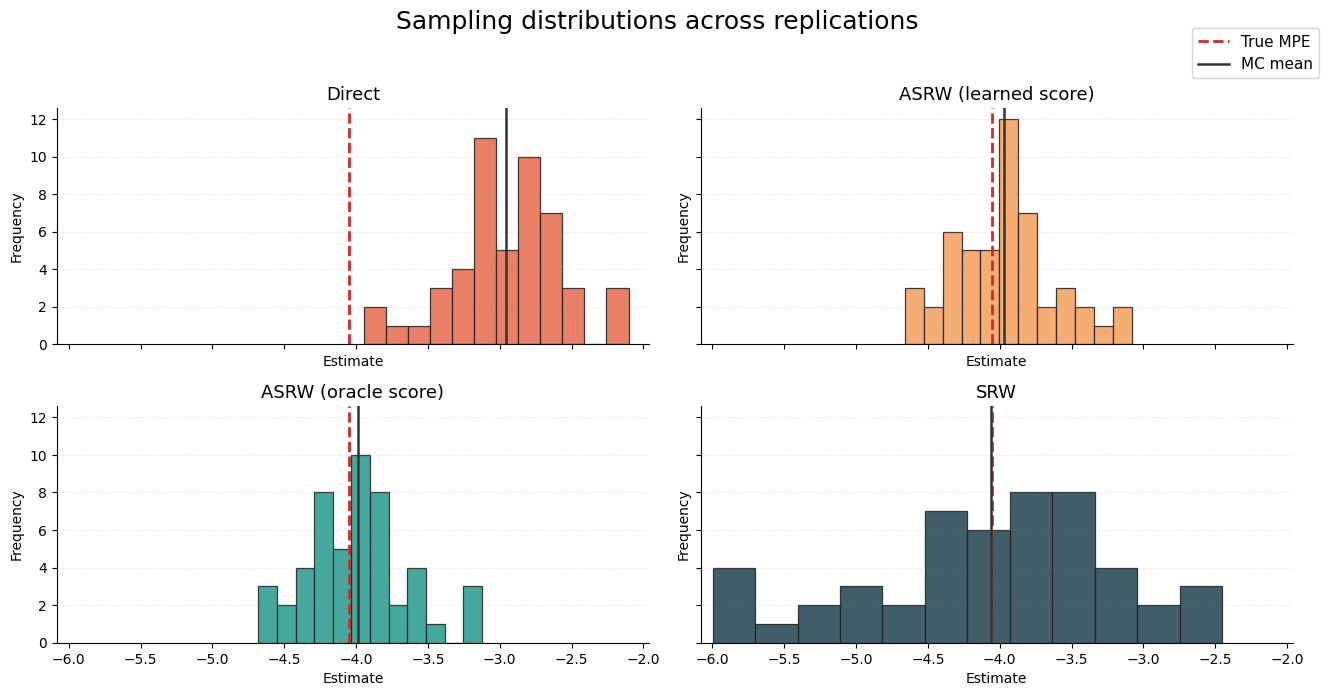

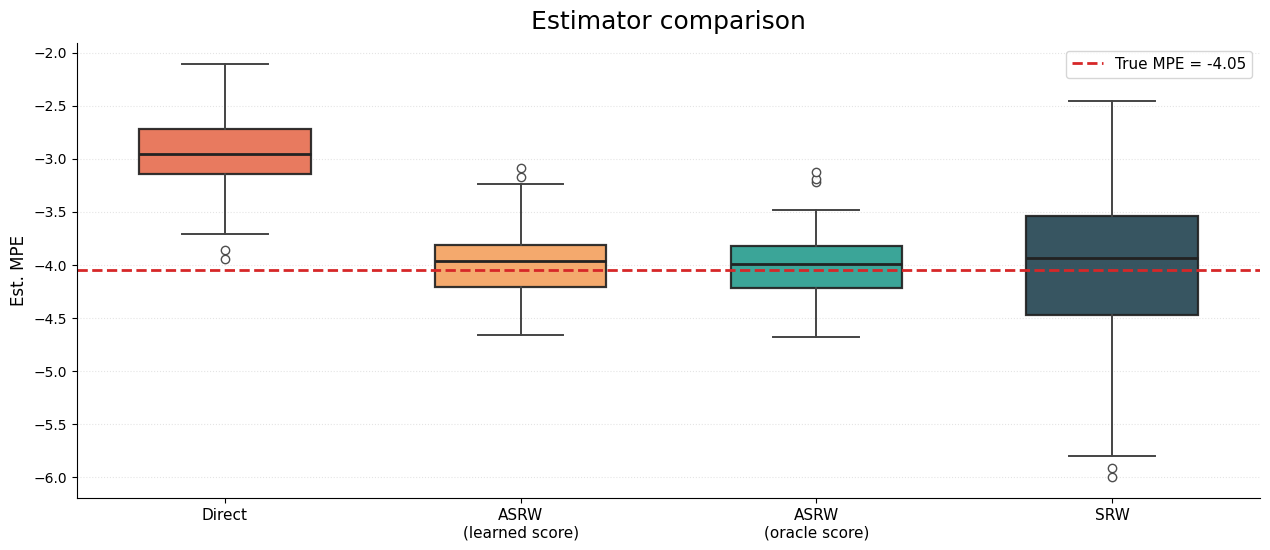

In [9]:
dgp = PricingDGPConfig(T=8)
learner = LearnerConfig()
mc = MonteCarloConfig(
    N=5000,
    R=50,
    n_folds=5,
    n_jobs=-1,
    se_method="iid",
)

out = run_simulation(dgp=dgp, learner=learner, mc=mc)
plot_estimator_histograms(out)
plot_estimator_boxplots(out)
